In [19]:
import json
import matplotlib.pyplot as plt

# Fixed categorical colors -- one per model class, consistent across every
# per-table plot below (color follows the entity, never plot order/rank).
COLOR = {
    "posts": "#2a78d6",     # blue
    "entities": "#1baf7a",  # aqua
    "accounts": "#eda100",  # yellow
    "actions": "#008300",   # green
}
INK = "#0b0b0b"
MUTED = "#898781"
GRID = "#e1e0d9"
SURFACE = "#fcfcfb"

PARALLEL_WORKERS = 8  # must match config.PARALLEL_NUM_WORKERS

# For single-series-per-mode charts (throughput, DB size), the mode itself is
# the entity being compared, so each mode gets its own color; for per-table
# charts (flush throughput, chunk growth) color stays per-table and mode is
# distinguished by marker/linestyle instead, so table identity isn't lost.
MODES = {
    "single": {
        "label": "Single-threaded (1 worker)",
        "color": COLOR["posts"],
        "marker": "o",
        "linestyle": "-",
    },
    f"parallel{PARALLEL_WORKERS}": {
        "label": f"Parallel ({PARALLEL_WORKERS} workers)",
        "color": COLOR["accounts"],
        "marker": "s",
        "linestyle": "--",
    },
}

plt.rcParams.update({
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "axes.edgecolor": MUTED,
    "axes.labelcolor": INK,
    "text.color": INK,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "grid.color": GRID,
    "font.size": 11,
})

In [20]:
LOGS_DIR = "/cta/users/anajafi/SMDT/benchmark_scripts/logs"

def _load_jsonl(path):
    try:
        with open(path) as f:
            return [json.loads(line) for line in f if line.strip()]
    except FileNotFoundError:
        return None

results_by_mode = {}
memory_by_mode = {}
for mode in MODES:
    r = _load_jsonl(f"{LOGS_DIR}/results_{mode}.jsonl")
    m = _load_jsonl(f"{LOGS_DIR}/memory_samples_{mode}.jsonl")
    if r is None:
        print(f"[{mode}] no results file yet -- that run hasn't started or hasn't reached a checkpoint.")
        continue
    results_by_mode[mode] = sorted(r, key=lambda x: x["checkpoint"])
    memory_by_mode[mode] = m or []
    print(f"[{mode}] {len(r)} checkpoint(s) completed: {[x['checkpoint'] for x in results_by_mode[mode]]}, "
          f"{len(memory_by_mode[mode])} memory samples")

print("\n(Re-run this cell + the plots below any time to refresh as more checkpoints land.)")

[single] 5 checkpoint(s) completed: [1000, 10000, 100000, 1000000, 10000000], 5712 memory samples
[parallel8] 5 checkpoint(s) completed: [1000, 10000, 100000, 1000000, 10000000], 6376 memory samples

(Re-run this cell + the plots below any time to refresh as more checkpoints land.)


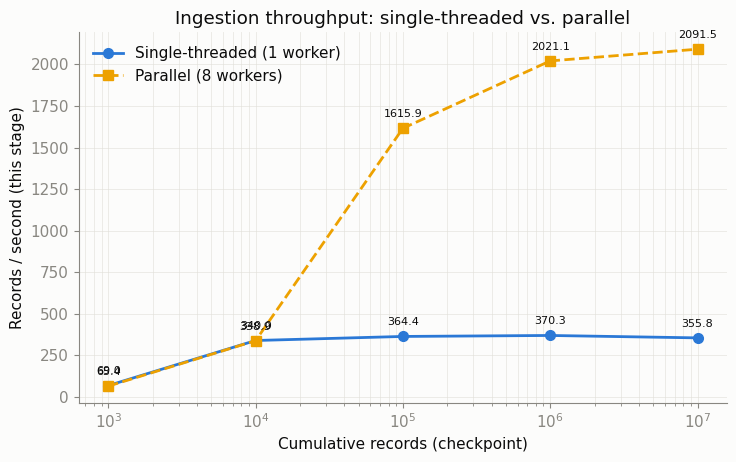

Checkpoint      Single (s)   Parallel (s)   Speedup
       1,000         14.5           15.3     0.95x
      10,000         26.5           26.6     1.00x
     100,000        247.0           55.7     4.43x
   1,000,000       2430.6          445.3     5.46x
  10,000,000      25295.1         4303.1     5.88x


In [21]:
# Plot 1: Ingestion throughput vs. dataset scale -- single-threaded vs. parallel
fig, ax = plt.subplots(figsize=(7.5, 4.75))

for mode, style in MODES.items():
    data = results_by_mode.get(mode)
    if not data:
        continue
    checkpoints = [r["checkpoint"] for r in data]
    rates = [r["records_per_second_this_stage"] for r in data]
    ax.plot(checkpoints, rates, marker=style["marker"], linestyle=style["linestyle"],
            color=style["color"], linewidth=2, markersize=7, label=style["label"])
    for x, y in zip(checkpoints, rates):
        ax.annotate(f"{y:.1f}", (x, y), textcoords="offset points", xytext=(0, 8),
                    ha="center", fontsize=8, color=INK)

ax.set_xscale("log")
ax.set_xlabel("Cumulative records (checkpoint)")
ax.set_ylabel("Records / second (this stage)")
ax.set_title("Ingestion throughput: single-threaded vs. parallel")
ax.grid(True, which="both", linewidth=0.6, alpha=0.7)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

# Speedup table, wherever both modes have reached the same checkpoint
single_by_ckpt = {r["checkpoint"]: r for r in results_by_mode.get("single", [])}
parallel_by_ckpt = {r["checkpoint"]: r for r in results_by_mode.get(f"parallel{PARALLEL_WORKERS}", [])}
common = sorted(set(single_by_ckpt) & set(parallel_by_ckpt))
if common:
    print("Checkpoint      Single (s)   Parallel (s)   Speedup")
    for c in common:
        s, p = single_by_ckpt[c]["elapsed_seconds"], parallel_by_ckpt[c]["elapsed_seconds"]
        print(f"{c:>12,}   {s:>10.1f}   {p:>12.1f}   {s / p:>6.2f}x")

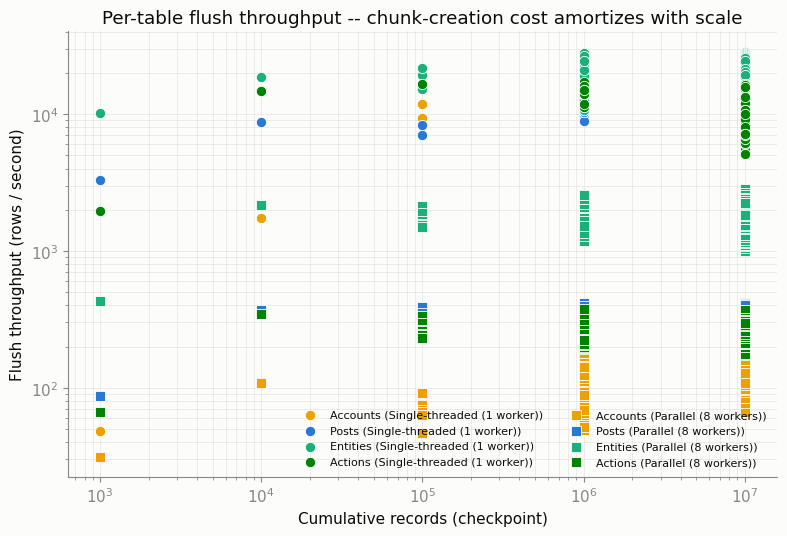

In [22]:
# Plot 2: Per-table flush throughput -- the chunk warm-up story, single vs. parallel.
# Each point is one flush event (a table can flush multiple times within a
# single checkpoint once its buffer crosses batch_size), so this also shows
# intra-checkpoint variance, not just one number per checkpoint. Color stays
# per-table (that's the entity here); marker shape distinguishes mode.
fig, ax = plt.subplots(figsize=(8, 5.5))

for mode, style in MODES.items():
    data = results_by_mode.get(mode)
    if not data:
        continue
    by_model = {}
    for r in data:
        for fe in r["flush_events"]:
            model = fe["model"].lower()
            if fe.get("elapsed", 0) <= 0:
                continue
            rate = fe["count"] / fe["elapsed"]
            by_model.setdefault(model, {"x": [], "y": []})
            by_model[model]["x"].append(r["checkpoint"])
            by_model[model]["y"].append(rate)

    for model in ["accounts", "posts", "entities", "actions"]:
        if model not in by_model:
            continue
        xy = by_model[model]
        ax.scatter(xy["x"], xy["y"], color=COLOR[model], marker=style["marker"],
                   label=f"{model.capitalize()} ({style['label']})",
                   s=55, zorder=3, edgecolor="white", linewidth=0.6)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Cumulative records (checkpoint)")
ax.set_ylabel("Flush throughput (rows / second)")
ax.set_title("Per-table flush throughput -- chunk-creation cost amortizes with scale")
ax.grid(True, which="both", linewidth=0.6, alpha=0.7)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False, loc="lower right", fontsize=8, ncol=2)

plt.tight_layout()
plt.show()

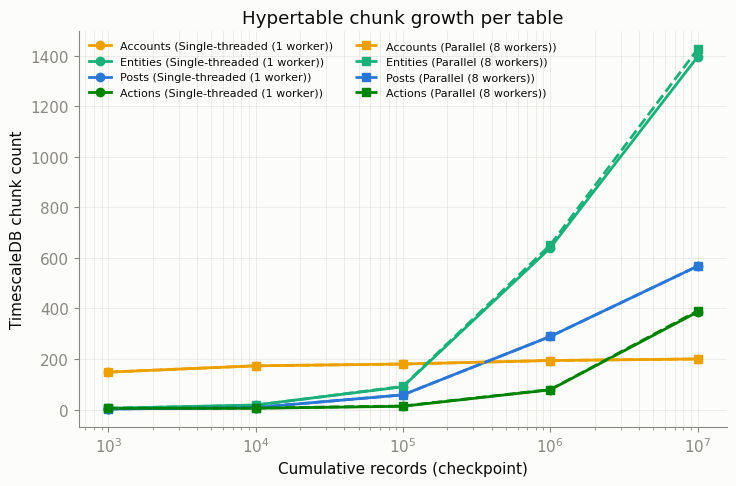

In [23]:
# Plot 3: Hypertable chunk growth per table, single vs. parallel
fig, ax = plt.subplots(figsize=(7.5, 5))

for mode, style in MODES.items():
    data = results_by_mode.get(mode)
    if not data:
        continue
    checkpoints_m = [r["checkpoint"] for r in data]
    for t in ["accounts", "entities", "posts", "actions"]:
        ys = [r["chunk_counts"].get(t, 0) for r in data]
        ax.plot(checkpoints_m, ys, marker=style["marker"], linestyle=style["linestyle"],
                color=COLOR[t], label=f"{t.capitalize()} ({style['label']})",
                linewidth=2, markersize=6)

ax.set_xscale("log")
ax.set_xlabel("Cumulative records (checkpoint)")
ax.set_ylabel("TimescaleDB chunk count")
ax.set_title("Hypertable chunk growth per table")
ax.grid(True, which="both", linewidth=0.6, alpha=0.7)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False, fontsize=8, ncol=2)

plt.tight_layout()
plt.show()

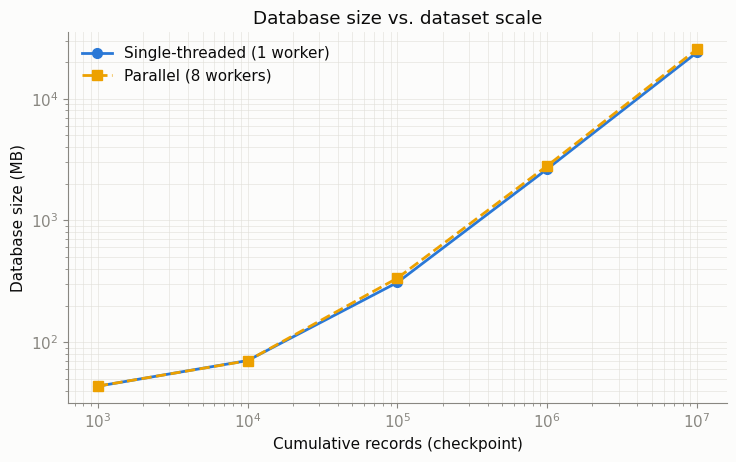

In [24]:
# Plot 4: Database size vs. dataset scale, single vs. parallel
# NOTE: parallel mode's dedup only happens within one file's buffer (each
# worker handles one file independently), while single-threaded mode dedupes
# across a much wider window (up to batch_size records, or the whole run
# below that) -- so posts/entities/actions, which lack a DB-level unique
# constraint, can end up with somewhat more rows in parallel mode. accounts/
# communities/*_enrichments aren't affected (they have a real unique
# constraint, so ON CONFLICT catches cross-file duplicates regardless of
# dedup scope). See PipelineConfig.num_workers' docstring for the full
# explanation. This means DB size differences between modes below partly
# reflect this, not purely "more real data."
fig, ax = plt.subplots(figsize=(7.5, 4.75))

for mode, style in MODES.items():
    data = results_by_mode.get(mode)
    if not data:
        continue
    checkpoints_m = [r["checkpoint"] for r in data]
    sizes_mb = [r["db_size_bytes"] / 1e6 for r in data]
    ax.plot(checkpoints_m, sizes_mb, marker=style["marker"], linestyle=style["linestyle"],
            color=style["color"], linewidth=2, markersize=7, label=style["label"])

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Cumulative records (checkpoint)")
ax.set_ylabel("Database size (MB)")
ax.set_title("Database size vs. dataset scale")
ax.grid(True, which="both", linewidth=0.6, alpha=0.7)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

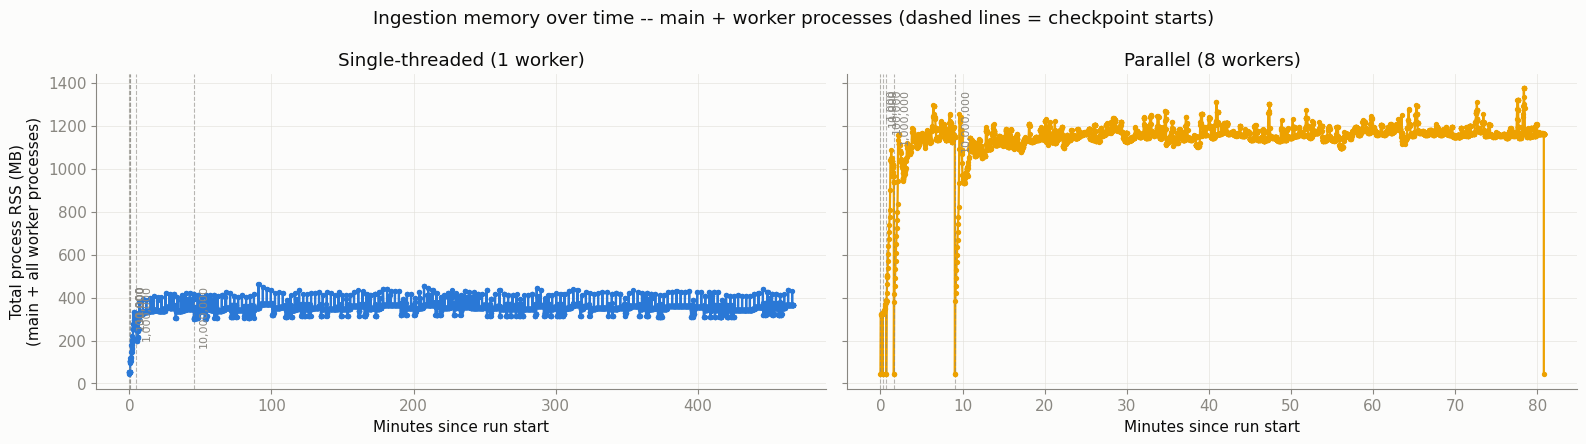

  Checkpoint    Single: peak total RSS (MB)   Parallel8: peak total RSS (MB)
       1,000                           54.7                            326.2
      10,000                          120.8                            388.6
     100,000                          331.0                           1088.5
   1,000,000                          423.4                           1295.6
  10,000,000                          461.6                           1375.8


In [25]:
# Plot 5: Process memory over time, single vs. parallel.
# rss_kb is total_rss_kb() from run_ingestion_benchmark.py -- self process +
# all live child (worker) processes, recursively. An earlier version of this
# benchmark sampled /proc/self/status only, which is correct for
# num_workers=1 but blind to worker memory under num_workers>1 (workers do
# all the standardizing/buffering in their own address space via
# ProcessPoolExecutor -- see pipeline.py's _run_parallel), making parallel
# mode look artificially low-memory. Fixed by summing self + all recursive
# children (psutil) on a periodic background-thread sample, independent of
# pipeline progress events -- see PeriodicMemorySampler.
#
# Side-by-side subplots (not overlaid) -- the two runs have very different
# durations, so a shared "minutes since start" x-axis wouldn't compare
# meaningfully. Y-axis is shared so magnitude is directly comparable.
active_modes = [m for m in MODES if memory_by_mode.get(m)]
fig, axes = plt.subplots(1, len(active_modes), figsize=(8 * len(active_modes), 4.5), sharey=True)
if len(active_modes) == 1:
    axes = [axes]

for ax, mode in zip(axes, active_modes):
    style = MODES[mode]
    samples = memory_by_mode[mode]
    t0 = samples[0]["timestamp"]
    xs = [(m["timestamp"] - t0) / 60 for m in samples]  # minutes since start
    ys = [m["rss_kb"] / 1024 for m in samples]  # MB

    ax.plot(xs, ys, color=style["color"], linewidth=1.6)
    ax.scatter(xs, ys, color=style["color"], s=8, zorder=3)

    seen = set()
    for x, m in zip(xs, samples):
        ck = m["checkpoint"]
        if ck in seen:
            continue
        seen.add(ck)
        ax.axvline(x, color=MUTED, linewidth=0.8, linestyle="--", alpha=0.6)
        ax.annotate(f"{ck:,}", (x, max(ys)), textcoords="offset points", xytext=(4, 0),
                    fontsize=8, color=MUTED, rotation=90, va="top")

    ax.set_xlabel("Minutes since run start")
    ax.set_title(style["label"])
    ax.grid(True, linewidth=0.6, alpha=0.7)
    ax.spines[["top", "right"]].set_visible(False)

axes[0].set_ylabel("Total process RSS (MB)\n(main + all worker processes)")
fig.suptitle("Ingestion memory over time -- main + worker processes (dashed lines = checkpoint starts)")
plt.tight_layout()
plt.show()

# Corrected peak total memory per checkpoint (self + all live workers at
# sample time) -- see run_checkpoint()'s stage_peak tracking. This is the
# number that's actually comparable between num_workers=1 and >1; the
# process's own self-only high-water mark (peak_rss_kb_since_process_start)
# is kept in the raw results for continuity but is NOT comparable across
# modes (it misses worker memory entirely under num_workers>1).
print(f"{'Checkpoint':>12} {'Single: peak total RSS (MB)':>30} {'Parallel8: peak total RSS (MB)':>32}")
for c in sorted(set(single_by_ckpt) & set(parallel_by_ckpt)):
    s_peak = single_by_ckpt[c].get("peak_total_rss_kb_this_stage")
    p_peak = parallel_by_ckpt[c].get("peak_total_rss_kb_this_stage")
    s_mb = f"{s_peak / 1024:.1f}" if s_peak else "n/a"
    p_mb = f"{p_peak / 1024:.1f}" if p_peak else "n/a"
    print(f"{c:>12,} {s_mb:>30} {p_mb:>32}")

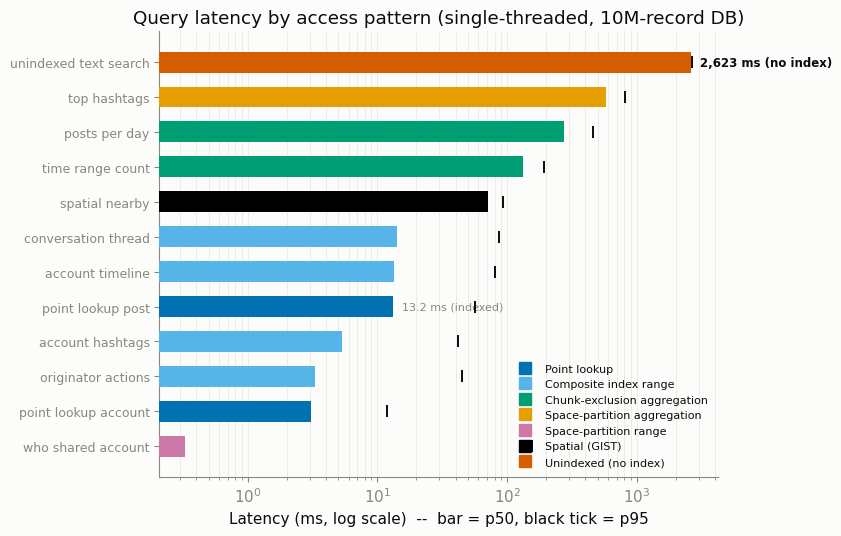

Unindexed ILIKE scan vs. indexed point lookup: 198x slower (2623ms vs 13.2ms)


In [26]:
# Plot 6: Query-speed benchmark -- indexed vs. unindexed access patterns,
# single-threaded mode's final 10M-record DB (see query_benchmarking.md for
# the full methodology and the time-window sampling bug found along the way).
#
# Categorical colors here are a dedicated palette (not COLOR/MODES above) --
# "query category" is a different identity axis than "table", so reusing
# table colors would visually conflate the two. Colors are the Okabe-Ito
# colorblind-safe qualitative set (Okabe & Ito, 2008), a peer-reviewed
# CVD-safe reference palette, not matplotlib's default cycle.
QUERY_CAT_COLOR = {
    "point_lookup": "#0072B2",
    "composite_index_range": "#56B4E9",
    "chunk_exclusion_aggregation": "#009E73",
    "space_partition_aggregation": "#E69F00",
    "space_partition_range": "#CC79A7",
    "spatial_gist": "#000000",
    "unindexed_contrast": "#D55E00",
}
QUERY_CAT_LABEL = {
    "point_lookup": "Point lookup",
    "composite_index_range": "Composite index range",
    "chunk_exclusion_aggregation": "Chunk-exclusion aggregation",
    "space_partition_aggregation": "Space-partition aggregation",
    "space_partition_range": "Space-partition range",
    "spatial_gist": "Spatial (GIST)",
    "unindexed_contrast": "Unindexed (no index)",
}

query_results = _load_jsonl(f"{LOGS_DIR}/query_benchmark_single.jsonl")
if not query_results:
    print("No query_benchmark_single.jsonl yet -- run query_benchmark.py first.")
else:
    rows = [r for r in query_results if not r.get("skipped")]
    rows.sort(key=lambda r: r["pooled_stats"]["p50_ms"])

    fig, ax = plt.subplots(figsize=(8.5, 5.5))
    y_pos = range(len(rows))
    p50s = [r["pooled_stats"]["p50_ms"] for r in rows]
    p95s = [r["pooled_stats"]["p95_ms"] for r in rows]
    colors = [QUERY_CAT_COLOR[r["category"]] for r in rows]
    names = [r["name"].replace("_", " ") for r in rows]

    ax.barh(y_pos, p50s, color=colors, height=0.6, zorder=3)
    # p95 as a thin tick past the bar end, not a second bar -- the bar's job
    # is p50 magnitude; p95 is a secondary spread indicator.
    ax.scatter(p95s, y_pos, marker="|", color=INK, s=80, zorder=4, linewidth=1.4)

    ax.set_yticks(list(y_pos))
    ax.set_yticklabels(names, fontsize=9)
    ax.set_xscale("log")
    ax.set_xlabel("Latency (ms, log scale)  --  bar = p50, black tick = p95")
    ax.set_title("Query latency by access pattern (single-threaded, 10M-record DB)")
    ax.grid(True, which="both", axis="x", linewidth=0.6, alpha=0.7)
    ax.spines[["top", "right"]].set_visible(False)

    # Direct label only the headline finding, not every bar (selective
    # labeling, not a number on every point).
    for r, y, p50 in zip(rows, y_pos, p50s):
        if r["name"] == "unindexed_text_search":
            ax.annotate(f"{p50:,.0f} ms (no index)", (p50, y), textcoords="offset points",
                        xytext=(6, 0), va="center", fontsize=8.5, color=INK, fontweight="bold")
        elif r["name"] == "point_lookup_post":
            ax.annotate(f"{p50:.1f} ms (indexed)", (p50, y), textcoords="offset points",
                        xytext=(6, 0), va="center", fontsize=8, color=MUTED)

    legend_handles = [
        plt.Line2D([0], [0], marker="s", linestyle="", color=c, markersize=9, label=QUERY_CAT_LABEL[cat])
        for cat, c in QUERY_CAT_COLOR.items()
        if cat in {r["category"] for r in rows}
    ]
    ax.legend(handles=legend_handles, frameon=False, fontsize=8, loc="lower right")

    plt.tight_layout()
    plt.show()

    unindexed = next((r for r in rows if r["name"] == "unindexed_text_search"), None)
    indexed = next((r for r in rows if r["name"] == "point_lookup_post"), None)
    if unindexed and indexed:
        ratio = unindexed["pooled_stats"]["p50_ms"] / indexed["pooled_stats"]["p50_ms"]
        print(f"Unindexed ILIKE scan vs. indexed point lookup: {ratio:.0f}x slower "
              f"({unindexed['pooled_stats']['p50_ms']:.0f}ms vs {indexed['pooled_stats']['p50_ms']:.1f}ms)")


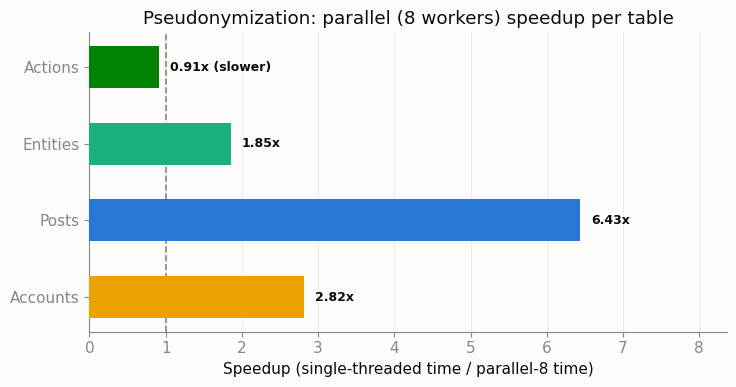

Table          Single (s)  Parallel8 (s)   Speedup
Accounts            266.8           94.7     2.82x
Posts             20142.7         3130.9     6.43x
Entities           9856.2         5315.7     1.85x
Actions            1166.5         1278.8     0.91x
TOTAL             31432.1         9820.1     3.20x


In [27]:
# Plot 7: Pseudonymization -- parallel (8 workers) speedup per table, full
# dataset, complete run (see pseudonymizer_benchamrk.md for the full story,
# including the two real _select_iter bugs found before these numbers meant
# anything). Color stays per-table (COLOR above), consistent with Plots 2-3.
#
# Not a uniform win, by design of what we're showing here: transform (the
# only thing num_workers parallelizes -- fetch/flush stay single-owner) was
# 90% of posts' time but only 14% of actions' (flush-dominated instead), so
# actions has too little parallelizable work to offset process-pool
# overhead -- it comes out slower, not faster. That's a real, not a
# smoothed-over finding.
pseudo_single = _load_jsonl(f"{LOGS_DIR}/pseudonymizer_benchmark_single.jsonl")
pseudo_parallel = _load_jsonl(f"{LOGS_DIR}/pseudonymizer_benchmark_parallel8.jsonl")

if not pseudo_single or not pseudo_parallel:
    print("Pseudonymization benchmark results not available for both modes yet.")
else:
    single_by_table = {r["table"]: r for r in pseudo_single if r.get("status") == "done"}
    parallel_by_table = {r["table"]: r for r in pseudo_parallel if r.get("status") == "done"}

    # communities/*_enrichments/dataset_meta are empty or a single row in
    # this ingestion-only benchmark DB -- not worth plotting.
    tables = ["accounts", "posts", "entities", "actions"]
    speedups = [single_by_table[t]["elapsed_s"] / parallel_by_table[t]["elapsed_s"] for t in tables]

    fig, ax = plt.subplots(figsize=(7.5, 4))
    y_pos = range(len(tables))
    colors = [COLOR[t] for t in tables]
    ax.barh(y_pos, speedups, color=colors, height=0.55, zorder=3)
    ax.set_xlim(0, max(speedups) * 1.3)

    ax.axvline(1.0, color=MUTED, linewidth=1.2, linestyle="--", zorder=2)
    ax.annotate("no benefit", (1.0, len(tables) - 0.3), textcoords="offset points",
                xytext=(4, 0), fontsize=8, color=MUTED)

    for y, sp, t in zip(y_pos, speedups, tables):
        label = f"{sp:.2f}x" + (" (slower)" if sp < 1 else "")
        ax.annotate(label, (sp, y), textcoords="offset points",
                    xytext=(8, 0), va="center", fontsize=9, color=INK, fontweight="bold")

    ax.set_yticks(list(y_pos))
    ax.set_yticklabels([t.capitalize() for t in tables])
    ax.set_xlabel("Speedup (single-threaded time / parallel-8 time)")
    ax.set_title("Pseudonymization: parallel (8 workers) speedup per table")
    ax.grid(True, axis="x", linewidth=0.6, alpha=0.7)
    ax.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    plt.show()

    print(f"{'Table':<12} {'Single (s)':>12} {'Parallel8 (s)':>14} {'Speedup':>9}")
    total_s = total_p = 0.0
    for t in tables:
        s, p = single_by_table[t]["elapsed_s"], parallel_by_table[t]["elapsed_s"]
        total_s += s
        total_p += p
        print(f"{t.capitalize():<12} {s:>12.1f} {p:>14.1f} {s / p:>8.2f}x")
    print(f"{'TOTAL':<12} {total_s:>12.1f} {total_p:>14.1f} {total_s / total_p:>8.2f}x")
